In [7]:
!pip install scikit-image
!pip install skimage

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/11.9 MB 18.5 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/11.9 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 21.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 19.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\athay\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached skimage-0.0.tar.gz (757 bytes)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [3 lines of output]
      
      *** Please install the `scikit-image` package (instead of `skimage`) ***
      
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\athay\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [1]:
import kagglehub
import os
os.environ['KAGGLE_USERNAME'] = 'athayanaufal'
os.environ['KAGGLE_KEY'] = 'ffd4e2414842d9aa07e4b650613b758d'
# Download latest version
path = kagglehub.competition_download('digit-recognizer')

print("Path to competition files:", path)

C:\Users\athay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 15.3M/15.3M [00:01<00:00, 8.94MB/s]

Extracting files...


Path to competition files: C:\Users\athay\.cache\kagglehub\competitions\digit-recognizer


In [2]:
import pandas as pd

# Read the data
train_file = os.path.join(path, 'train.csv')
test_file = os.path.join(path, 'test.csv')

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

# Display first few rows
train_df.head()
test_df.head()


Train data shape: (42000, 785)
Test data shape: (28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


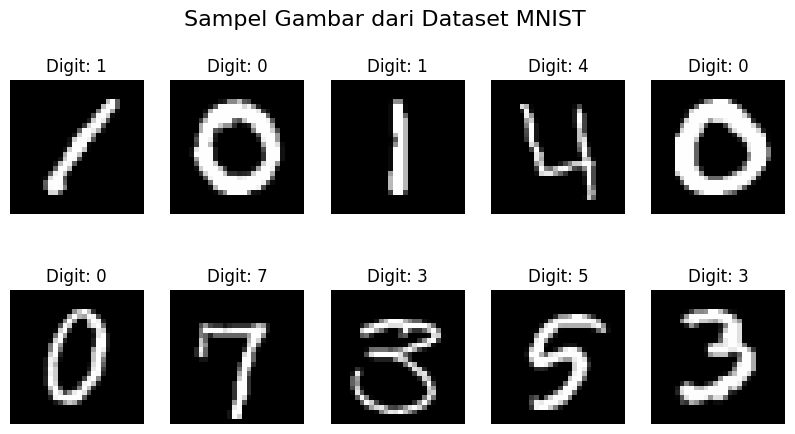

C:\Users\athay\AppData\Local\Temp\ipykernel_23452\733946542.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='viridis')


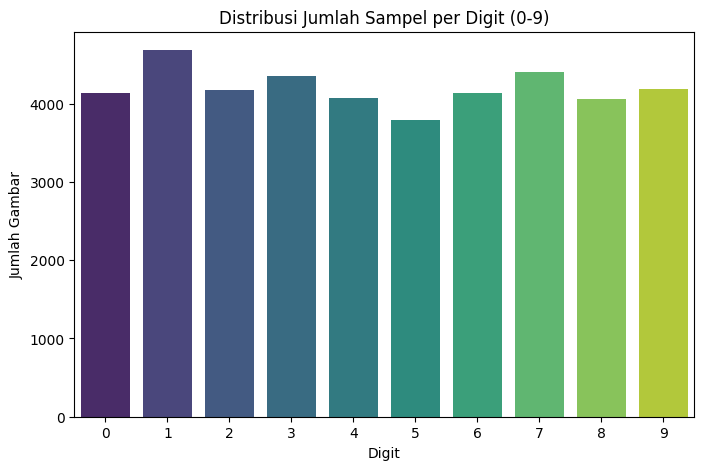

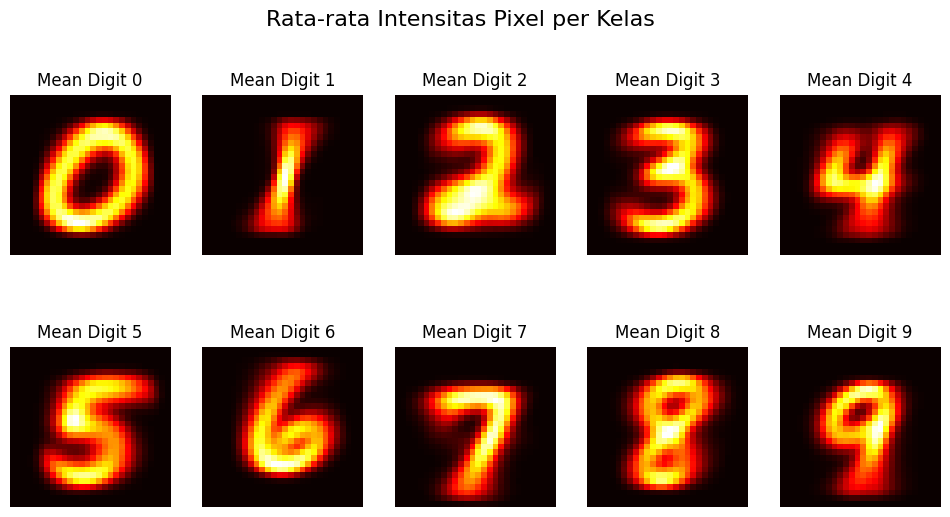

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)

    img = train_df.iloc[i, 1:].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Digit: {train_df.iloc[i, 0]}")
    plt.axis('off')
plt.suptitle("Sampel Gambar dari Dataset MNIST", fontsize=16)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train_df, palette='viridis')
plt.title('Distribusi Jumlah Sampel per Digit (0-9)')
plt.xlabel('Digit')
plt.ylabel('Jumlah Gambar')
plt.show()


mean_images = train_df.groupby('label').mean().values.reshape(10, 28, 28)
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(mean_images[i], cmap='hot')
    plt.title(f"Mean Digit {i}")
    plt.axis('off')
plt.suptitle("Rata-rata Intensitas Pixel per Kelas", fontsize=16)
plt.show()

In [ ]:
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

def extract_hog_features(df):
    hog_features = []
    for i in range(len(df)):
        img = df.iloc[i].values.reshape(28, 28) 
        
        fd = hog(img, orientations=9, pixels_per_cell=(7, 7),
                 cells_per_block=(2, 2), visualize=False)
        hog_features.append(fd)
        
    return np.array(hog_features)

X_raw = train_df.drop('label', axis=1)
y = train_df['label']

from sklearn.model_selection import train_test_split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_raw, y, test_size=0.2, random_state=42)

print("Mengekstrak fitur HOG..)")
X_train_hog = extract_hog_features(X_train_raw)
X_val_hog = extract_hog_features(X_val_raw)

# --- 3. TRAINING SVM ---
print("Training SVM dengan Fitur HOG...")
# Gunakan kernel rbf (default) atau linear
svm_hog = SVC(kernel='rbf', C=10, random_state=42)
svm_hog.fit(X_train_hog, y_train)

# --- 4. EVALUASI ---
y_pred_svm = svm_hog.predict(X_val_hog)
acc_svm = accuracy_score(y_val, y_pred_svm)

print(f"\n--- HOG + SVM Performance ---")
print(f"Accuracy: {acc_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_svm))

Mengekstrak fitur HOG..)
Training SVM dengan Fitur HOG...

--- HOG + SVM Performance ---
Accuracy: 0.9837

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       816
           1       0.99      0.99      0.99       909
           2       0.98      0.98      0.98       846
           3       0.98      0.97      0.98       937
           4       0.99      0.98      0.99       839
           5       0.99      0.98      0.98       702
           6       0.99      0.99      0.99       785
           7       0.98      0.98      0.98       893
           8       0.97      0.98      0.98       835
           9       0.97      0.98      0.98       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. PREPROCESSING DATA UNTUK CNN ---

X_train_cnn = X_train_raw.values.reshape(-1, 28, 28, 1) / 255.0
X_val_cnn = X_val_raw.values.reshape(-1, 28, 28, 1) / 255.0

# --- 2. MEMBANGUN ARSITEKTUR DEEP CNN (OPSI BONUS) ---
def build_deep_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2 (Lebih Dalam)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully Connected Layer
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax') # 10 kelas (0-9)
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# --- 3. TRAINING ---
deep_cnn = build_deep_cnn()
print("Training Deep CNN")

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = deep_cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop],
    verbose=1
)

# --- 4. EVALUASI ---
val_loss, val_acc = deep_cnn.evaluate(X_val_cnn, y_val, verbose=0)
print(f"\n--- Deep CNN Performance ---")
print(f"Validation Accuracy: {val_acc:.4f}")

C:\Users\athay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deep CNN
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 48s 85ms/step - accuracy: 0.9322 - loss: 0.2233 - val_accuracy: 0.9457 - val_loss: 0.1961
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 48s 92ms/step - accuracy: 0.9760 - loss: 0.0783 - val_accuracy: 0.9812 - val_loss: 0.0612
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 55s 104ms/step - accuracy: 0.9809 - loss: 0.0624 - val_accuracy: 0.9907 - val_loss: 0.0311
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 58s 110ms/step - accuracy: 0.9846 - loss: 0.0495 - val_accuracy: 0.9848 - val_loss: 0.0440
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 48s 91ms/step - accuracy: 0.9853 - loss: 0.0480 - val_accuracy: 0.9882 - val_loss: 0.0332
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - accuracy: 0.9870 - loss: 0.0402 - val_accuracy: 0.9901 - val_loss: 0.0298
Epoch 7/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 69s 132ms/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9887 - val_loss: 0.0381
Epoch 8/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - accuracy: 0.

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


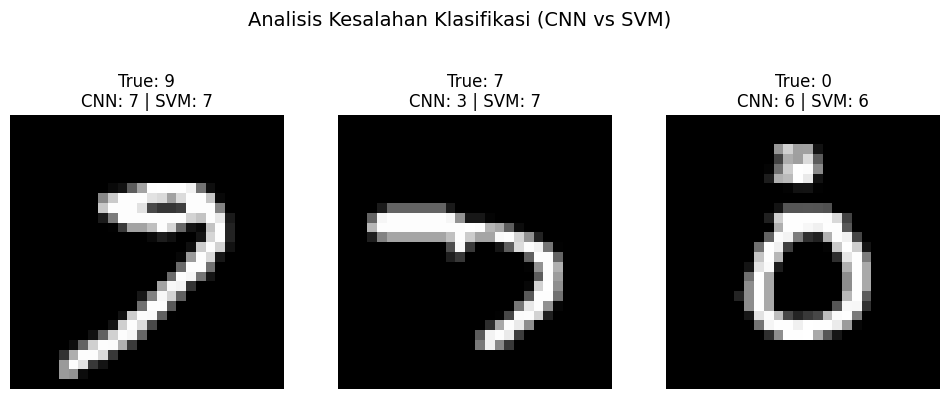

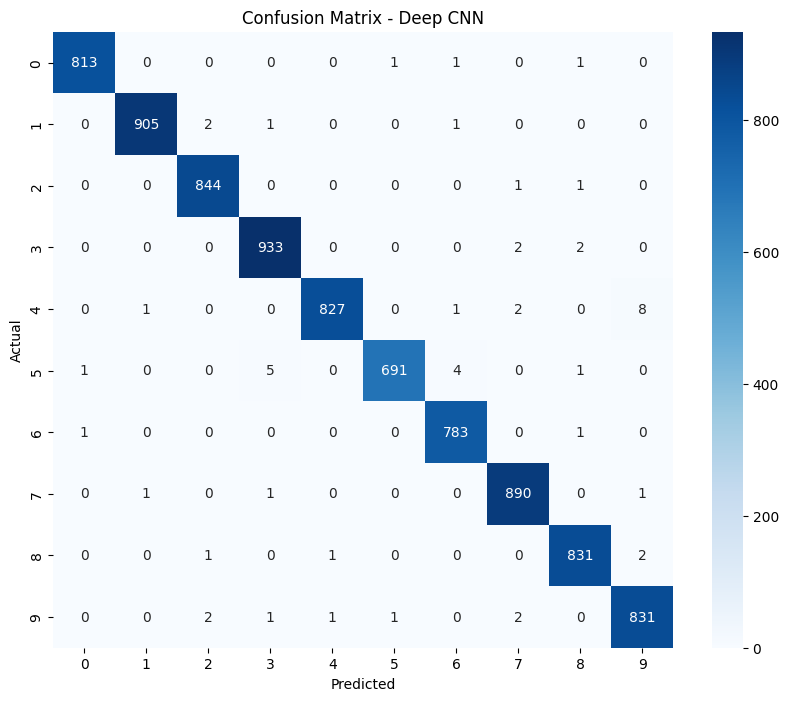

In [12]:
# --- 1. PREDIKSI ---
# Prediksi kelas dari CNN
cnn_probs = deep_cnn.predict(X_val_cnn)
cnn_preds = np.argmax(cnn_probs, axis=1)

# --- 2. IDENTIFIKASI KESALAHAN ---
# Mencari indeks di mana prediksi tidak sama dengan label asli
misclassified_idx = np.where(cnn_preds != y_val.values)[0]

# --- 3. VISUALISASI 3 CONTOH KESALAHAN (Syarat Soal Poin 72) ---
plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified_idx[:3]):
    plt.subplot(1, 3, i+1)
    img = X_val_cnn[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    
    actual_label = y_val.values[idx]
    predicted_label = cnn_preds[idx]
    
    # Ambil juga prediksi dari SVM untuk perbandingan (jika ada di variabel y_pred_svm)
    svm_label = y_pred_svm[idx]
    
    plt.title(f"True: {actual_label}\nCNN: {predicted_label} | SVM: {svm_label}")
    plt.axis('off')

plt.suptitle("Analisis Kesalahan Klasifikasi (CNN vs SVM)", fontsize=14)
plt.show()

# --- 4. CONFUSION MATRIX (Syarat Soal Poin 42) ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, cnn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Deep CNN')
plt.show()